# DAPI Image Display Debugging

In [5]:
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pathlib

## Helper

In [6]:
def grayscale_to_rgb(grayscale_img):
    # Squeeze singleton dimension if present
    if grayscale_img.ndim == 3 and grayscale_img.shape[0] == 1:
        grayscale_img = np.squeeze(grayscale_img, axis=0)
    # Normalize to 0-255
    img_normalized = cv2.normalize(grayscale_img, None, 0, 255, cv2.NORM_MINMAX)
    img_normalized = img_normalized.astype(np.uint8)
    img_rgb = cv2.cvtColor(img_normalized, cv2.COLOR_GRAY2RGB)
    return img_rgb

In [7]:
# clip outliers before noramlization
def remove_outliers(img, k=18.0, use_median=False):
    """
    Clip values that are more than k std-dev (or MAD units) above center.
    Args:
        img: 16-bit numpy array
        k: threshold (e.g. 3σ)
        use_median: if True use median+MAD, else mean+std
    Returns:
        clipped float32 image in [0,1]
    """

    print("OUTLIERS REMOVING...")
    x = img.astype(np.float32)

    if use_median:
        med = np.median(x)
        mad = np.median(np.abs(x - med)) + 1e-6
        sigma = 1.4826 * mad  # robust std estimate
        thresh = med + k * sigma
    else:
        mean = np.mean(x)
        std = np.std(x)
        thresh = mean + k * std

    # clip outliers
    x_clipped = np.minimum(x, thresh)

    # normalize after clipping (to 0..1)
    x_norm = (x_clipped - x_clipped.min()) / (x_clipped.max() - x_clipped.min() + 1e-6)
    return x_norm

## Understanding Issues

In [32]:
single_DAPI = pathlib.Path(r'C:\Users\tkpp2\Documents\FISH-ML2\assets\testing_DAPI\single_DAPI\single\MAX_KD1_w1-358 DAPI_s001.tif') 
zprojected_DAPI = pathlib.Path(r'C:\Users\tkpp2\Documents\FISH-ML2\assets\testing_DAPI\zprojected_DAPI\zprojected (reDAPI)\MAX_KD1_w1-358 reDAPI_s001.tif')
problematic_DAPI = pathlib.Path(r'C:\Users\tkpp2\Documents\FISH-ML2\assets\testing_DAPI\zprojected_DAPI\zprojected (reDAPI)\MAX_KD1_w1-358 reDAPI_s001.tif')

single_pil = Image.open(single_DAPI)
zprojected_pil = Image.open(zprojected_DAPI)
problematic_pil = Image.open(problematic_DAPI)

single_np = np.array(single_pil)
print('Single image shape:', single_np.shape, 'dtype:', single_np.dtype, 'min:', single_np.min(), 'max:', single_np.max())
zprojected_np = np.array(zprojected_pil)
print('Z-projected image shape:', zprojected_np.shape, 'dtype:', zprojected_np.dtype, 'min:', zprojected_np.min(), 'max:', zprojected_np.max())
problematic_np = np.array(problematic_pil)
print('Loaded image shape:', problematic_np.shape, 'dtype:', problematic_np.dtype, 'min:', problematic_np.min(), 'max:', problematic_np.max())


Single image shape: (2048, 2048) dtype: uint16 min: 59 max: 4889
Z-projected image shape: (2048, 2048) dtype: >u2 min: 100 max: 6144
Loaded image shape: (2048, 2048) dtype: >u2 min: 100 max: 6144


In [ ]:
print('Single image: min: ', single_np.min(), ' max: ', single_np.max())
print('Z-projected image: min: ', zprojected_np.min(), ' max: ', zprojected_np.max())

In [33]:
import sys
sys.byteorder

'little'

>u2 where > means big endian while u2 means unsigned 2 byte integer which is equivalent to unit16 where pixel values range from 0 to 65535
min 100 means the darkest while the max value of 6144 is the brightest pixel value

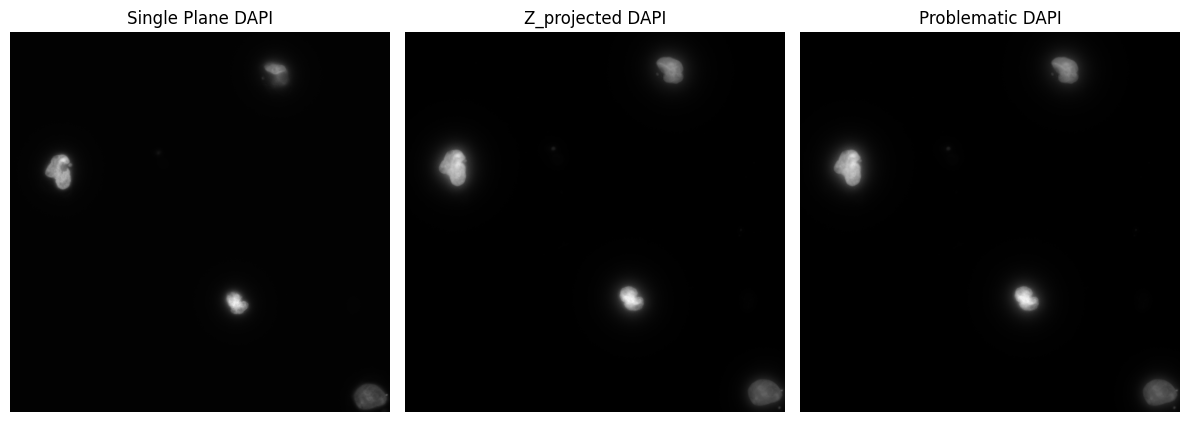

In [12]:
# Display in graysscale

fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes[0].imshow(single_np, cmap='gray')
axes[0].set_title('Single Plane DAPI')
axes[0].axis('off')

axes[1].imshow(zprojected_np, cmap='gray')
axes[1].set_title('Z_projected DAPI')
axes[1].axis('off')

axes[2].imshow(problematic_np, cmap='gray')
axes[2].set_title('Problematic DAPI')
axes[2].axis('off')

plt.tight_layout()
plt.show()


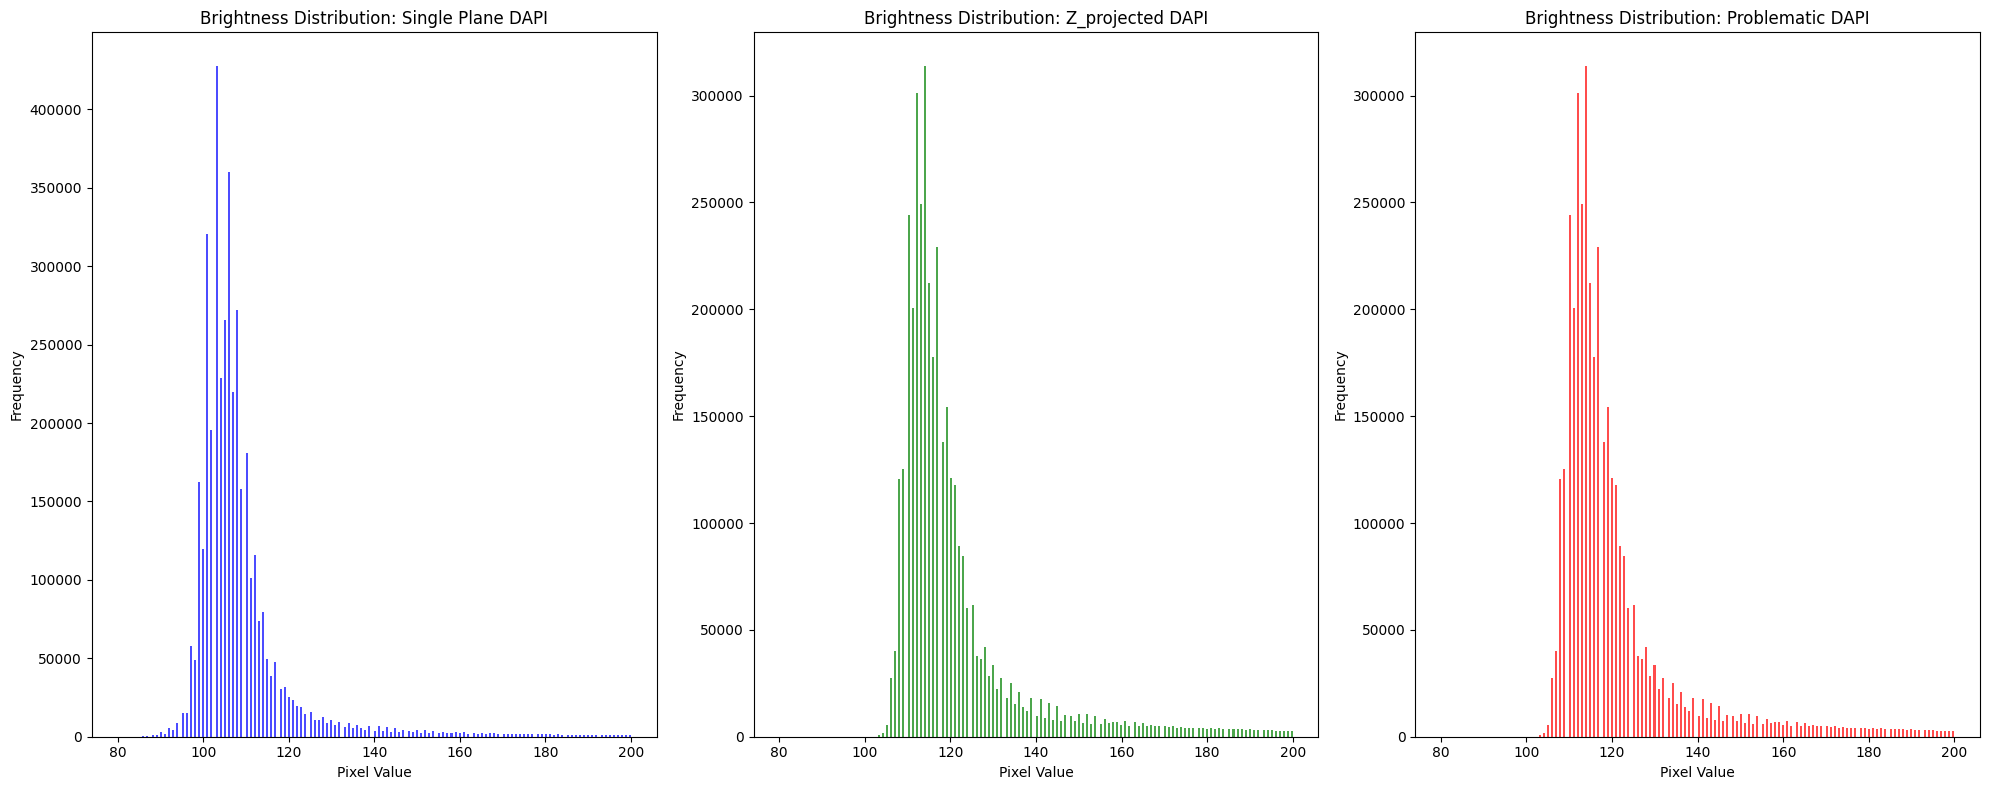

In [ ]:
# comparing brightness distributions
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

axes[0].hist(single_np.flatten(), bins=256, range=(80, 200), color='blue', alpha=0.7)
axes[0].set_title('Brightness Distribution: Single Plane DAPI')
axes[0].set_xlabel('Pixel Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(zprojected_np.flatten(), bins=256, range=(80, 200), color='green', alpha=0.7)
axes[1].set_title('Brightness Distribution: Z_projected DAPI')
axes[1].set_xlabel('Pixel Value')
axes[1].set_ylabel('Frequency')

axes[2].hist(problematic_np.flatten(), bins=256, range=(80, 200), color='red', alpha=0.7)
axes[2].set_title('Brightness Distribution: Problematic DAPI')
axes[2].set_xlabel('Pixel Value')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

larger range with 256 buckets, means most pixels pile up in just a few buckets, making the frequency high. smaller range with 256 buckets, means the pixels are spread out more evenly across more buckets, so the frequency for each pixel value decreases

distribution between s000 reDAPI and s001 reDAPI seems to be the same. Why would it work for s000 while we have to clip outliers for s001?

In [ ]:
# Compare distributions before swapping byte order
print("Stats for zprojected_np (s000, uint16):")
print(f"  Min: {zprojected_np.min()}, Max: {zprojected_np.max()}, Mean: {zprojected_np.mean():.2f}, Std: {zprojected_np.std():.2f}")

print("Stats for problematic_np (s001, >u2 - misinterpreted):")
print(f"  Min: {problematic_np.min()}, Max: {problematic_np.max()}, Mean: {problematic_np.mean():.2f}, Std: {problematic_np.std():.2f}")

Stats for zprojected_np (s000, uint16):
  Min: 100, Max: 6144, Mean: 195.34, Std: 412.08
Stats for problematic_np (s001, >u2 - misinterpreted):
  Min: 100, Max: 6144, Mean: 195.34, Std: 412.08


Seems like the distributions is similar. So it is wierd that we only have to clip the third one. Would this mean that the issue isn't necessarily because of outliers in brightness, but a image format issue? >u2 vs unit16?

Convert from >u2 to unit16 --
big endian to little endian --
big endian may have caused extreme values that resulted in blobs

In [ ]:
problematic_np = np.array(Image.open(r'C:\Users\Hong\FISH-ML2\assets\testing_dapi\MAX_KD1_w1-358 reDAPI_s001.tif'))

print("Dtype before:", problematic_np.dtype)

# Inspect raw bytes before byteswap
print("Before byteswap (big-endian >u2):")
print("First 10 bytes (hex):", problematic_np.tobytes()[:10].hex())
print("Last 10 bytes (hex):", problematic_np.tobytes()[-10:].hex())
print("First pixel value:", problematic_np.flat[0], "as bytes:", int(problematic_np.flat[0]).to_bytes(2, byteorder='big'))

# Apply byteswap to a new variable
if problematic_np.dtype == '>u2':
    problematic_little_np = problematic_np.byteswap().astype(np.uint16)
    print("Byteswap applied to new variable.")
else:
    problematic_little_np = problematic_np.copy()
    print("Byteswap skipped (dtype not >u2).")

print("Dtype after (swapped):", problematic_little_np.dtype)

# Inspect raw bytes after byteswap
print("\nAfter byteswap (little-endian uint16):")
print("First 10 bytes (hex):", problematic_little_np.tobytes()[:10].hex())
print("Last 10 bytes (hex):", problematic_little_np.tobytes()[-10:].hex())
print("First pixel value:", problematic_little_np.flat[0], "as bytes:", int(problematic_little_np.flat[0]).to_bytes(2, byteorder='little'))

# compare
print("\nComparison:")
print("Original min/max:", problematic_np.min(), problematic_np.max())
print("Swapped min/max:", problematic_little_np.min(), problematic_little_np.max())

Dtype before: >u2
Before byteswap (big-endian >u2):
First 10 bytes (hex): 00710071006e0077006d
Last 10 bytes (hex): 00f300fe00e900f70103
First pixel value: 113 as bytes: b'\x00q'
Byteswap applied to new variable.
Dtype after (swapped): uint16

After byteswap (little-endian uint16):
First 10 bytes (hex): 00710071006e0077006d
Last 10 bytes (hex): 00f300fe00e900f70103
First pixel value: 28928 as bytes: b'\x00q'

Comparison:
Original min/max: 100 6144
Swapped min/max: 1 65302


In [ ]:
problematic_clipped = remove_outliers(problematic_np, k=18.0, use_median=False)
problematic_little_clipped = remove_outliers(problematic_little_np, k=18.0, use_median=False)

OUTLIERS REMOVING...
OUTLIERS REMOVING...


try each step one at a time
        img_normalized = cv2.normalize(grayscale_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        img_rgb = cv2.cvtColor(img_normalized, cv2.COLOR_GRAY2RGB)
        brightness_factor = 1
        return np.clip(img_rgb * brightness_factor, 0, 255).astype(np.uint8)

In [ ]:
single_normalized = cv2.normalize(single_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
zprojected_normalized = cv2.normalize(zprojected_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
problematic_normalized = cv2.normalize(problematic_clipped, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
problematic_little_normalized = cv2.normalize(problematic_little_clipped, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
problematic_little_notclipped_normalized = cv2.normalize(problematic_little_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

print('Loaded image shape:', single_normalized.shape, 'dtype:', single_normalized.dtype, 'min:', single_normalized.min(), 'max:', single_normalized.max())
print('Loaded image shape:', zprojected_normalized.shape, 'dtype:', zprojected_normalized.dtype, 'min:', zprojected_normalized.min(), 'max:', zprojected_normalized.max())
print('Loaded image shape:', problematic_normalized.shape, 'dtype:', problematic_normalized.dtype, 'min:', problematic_normalized.min(), 'max:', problematic_normalized.max())
print('Loaded image shape:', problematic_little_normalized.shape, 'dtype:', problematic_little_normalized.dtype, 'min:', problematic_little_normalized.min(), 'max:', problematic_little_normalized.max())
print('Loaded image shape:', problematic_little_notclipped_normalized.shape, 'dtype:', problematic_little_notclipped_normalized.dtype, 'min:', problematic_little_notclipped_normalized.min(), 'max:', problematic_little_notclipped_normalized.max())

Loaded image shape: (2048, 2048) dtype: uint8 min: 0 max: 255
Loaded image shape: (2048, 2048) dtype: uint8 min: 0 max: 255
Loaded image shape: (2048, 2048) dtype: uint8 min: 0 max: 255
Loaded image shape: (2048, 2048) dtype: uint8 min: 0 max: 255
Loaded image shape: (2048, 2048) dtype: uint8 min: 0 max: 255


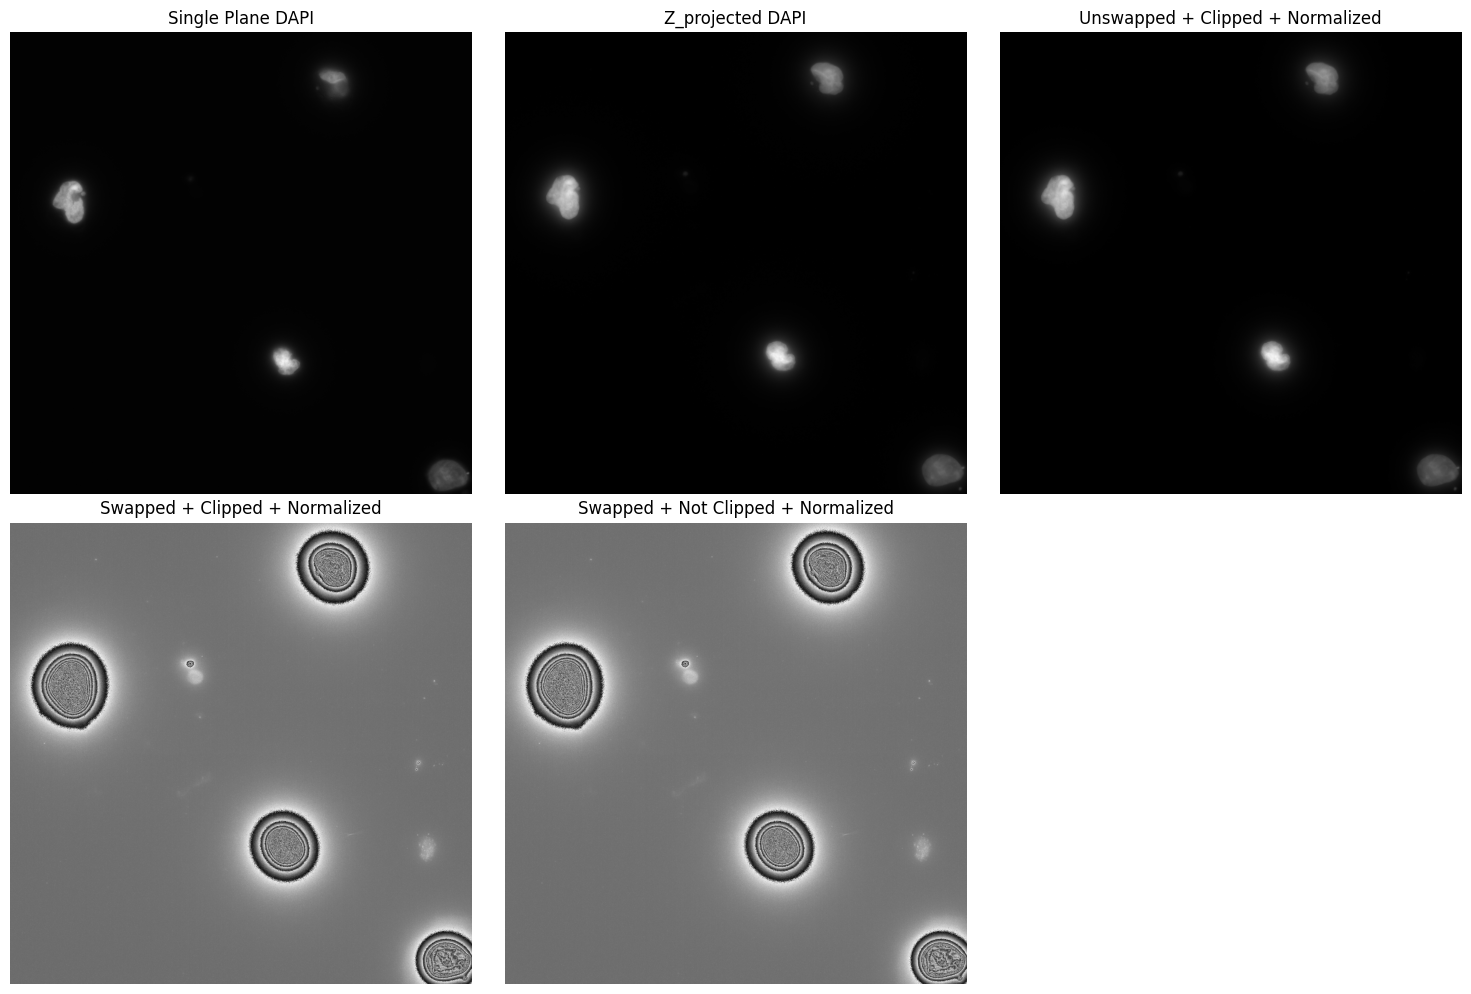

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].imshow(single_normalized, cmap='gray')
axes[0,0].set_title('Single Plane DAPI')
axes[0,0].axis('off')

axes[0,1].imshow(zprojected_normalized, cmap='gray')
axes[0,1].set_title('Z_projected DAPI')
axes[0,1].axis('off')

axes[0,2].imshow(problematic_normalized, cmap='gray')
axes[0,2].set_title('Unswapped + Clipped + Normalized')
axes[0,2].axis('off')

axes[1,0].imshow(problematic_little_normalized, cmap='gray')
axes[1,0].set_title('Swapped + Clipped + Normalized')
axes[1,0].axis('off')

axes[1,1].imshow(problematic_little_notclipped_normalized, cmap='gray')
axes[1,1].set_title('Swapped + Not Clipped + Normalized')
axes[1,1].axis('off')

# Hide the empty subplot
axes[1,2].set_visible(False)

plt.tight_layout()
plt.show()

Worked! Issue solved 
Issue : extreme outliers caused the blob for some reason

seems like when its not swapped and applied remove_outliers before noramlizing, it worked but if we swapped and applied remove_outliers it results in blob. So swapping doesnt seem to work, and simply removing outliers works, but this leads to the question again as to why we have to clip for this s001 but not for s000 which both seem to have the same pixel value distribution

## Conversion to Unit16

In [24]:
single_DAPI = pathlib.Path(r'C:\Users\tkpp2\Documents\FISH-ML2\assets\testing_DAPI\single_DAPI\single\MAX_KD1_w1-358 DAPI_s001.tif') 
zprojected_DAPI = pathlib.Path(r'C:\Users\tkpp2\Documents\FISH-ML2\assets\testing_DAPI\zprojected_DAPI\zprojected (reDAPI)\MAX_KD1_w1-358 reDAPI_s001.tif')

single_pil = Image.open(single_DAPI)
zprojected_pil = Image.open(zprojected_DAPI)

In [ ]:
def to_uint16_native(arr):
    if arr.dtype == '>u2':
        return arr.astype(np.uint16)
    return arr.astype(np.uint16, copy=False)

single_np = to_uint16_native(single_np)
zprojected_np = to_uint16_native(zprojected_np)
problematic_np = to_uint16_native(problematic_np)

# Verify
print('Single DAPI:',
      single_np.shape, single_np.dtype,
      'min:', single_np.min(), 'max:', single_np.max())

print('Z-projected DAPI:',
      zprojected_np.shape, zprojected_np.dtype,
      'min:', zprojected_np.min(), 'max:', zprojected_np.max())

Single DAPI: (2048, 2048) uint16 min: 59 max: 4889
Z-projected DAPI: (2048, 2048) uint16 min: 100 max: 6144


In [27]:
single_normalized = cv2.normalize(single_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
zprojected_normalized = cv2.normalize(zprojected_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

print('Loaded image shape:', single_normalized.shape, 'dtype:', single_normalized.dtype, 'min:', single_normalized.min(), 'max:', single_normalized.max())
print('Loaded image shape:', zprojected_normalized.shape, 'dtype:', zprojected_normalized.dtype, 'min:', zprojected_normalized.min(), 'max:', zprojected_normalized.max())

Loaded image shape: (2048, 2048) dtype: uint8 min: 0 max: 255
Loaded image shape: (2048, 2048) dtype: uint8 min: 0 max: 255


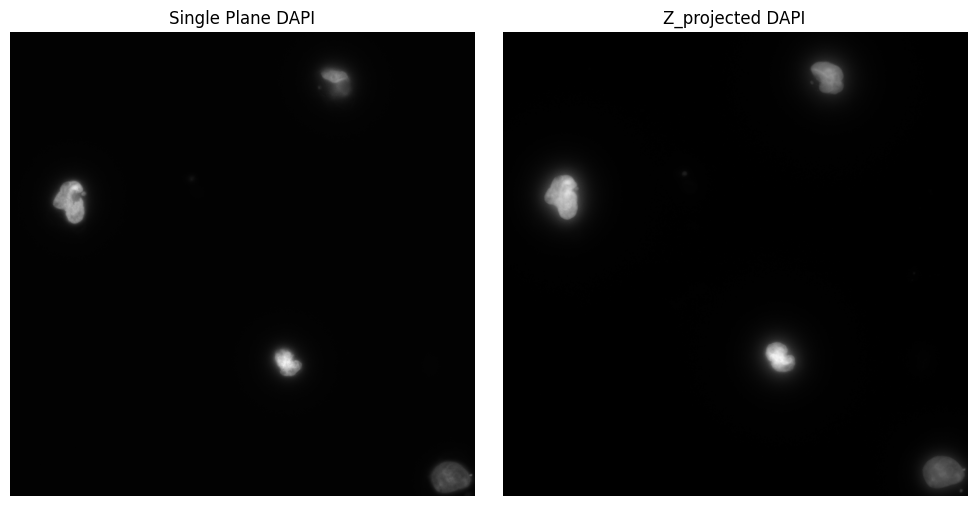

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(single_normalized, cmap='gray')
axes[0].set_title('Single Plane DAPI')
axes[0].axis('off')

axes[1].imshow(zprojected_normalized, cmap='gray')
axes[1].set_title('Z_projected DAPI')
axes[1].axis('off')

plt.tight_layout()
plt.show()

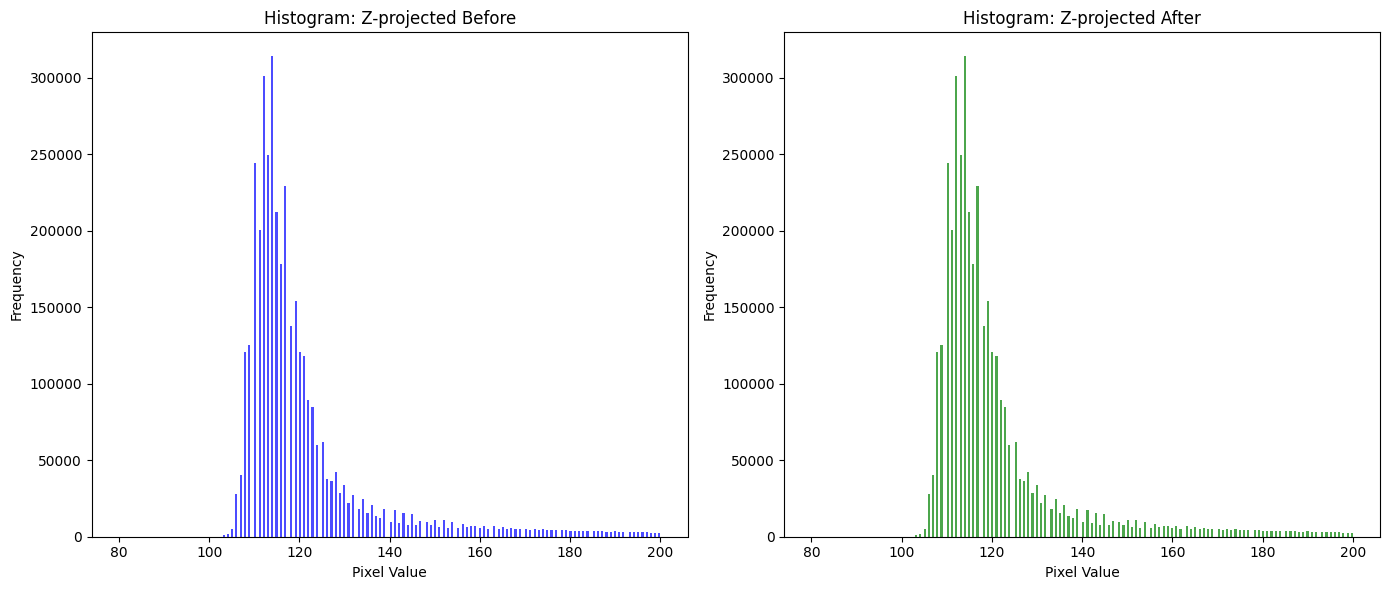

In [ ]:
zprojected_DAPI = pathlib.Path(r'C:\Users\tkpp2\Documents\FISH-ML2\assets\testing_DAPI\zprojected_DAPI\zprojected (reDAPI)\MAX_KD1_w1-358 reDAPI_s001.tif')
zprojected_pil = Image.open(zprojected_DAPI)
zprojected_np = to_uint16_native(zprojected_np)

zprojected_before = np.array(zprojected_pil)
zprojected_after = zprojected_np 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(zprojected_before.flatten(), bins=256, range=(80, 200), color='blue', alpha=0.7)
axes[0].set_title('Histogram: Z-projected Before')
axes[0].set_xlabel('Pixel Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(zprojected_after.flatten(), bins=256, range=(80, 200), color='green', alpha=0.7)
axes[1].set_title('Histogram: Z-projected After')
axes[1].set_xlabel('Pixel Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()